In [14]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageStat

In [15]:
# Load train dataset (image's id_codes and corresponding diagnoses)
train_df = pd.read_csv('../data/raw/aptos2019/train.csv')
print(f'Train dataset:\n{train_df.head()}')

Train dataset:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [16]:
# Check if the number of rows in the loaded dataset matches
# the number of files in the train images directory
print(f'Number of rows in train.csv: {len(train_df)}')
DIR_TRAIN = '../data/raw/aptos2019/train_images'
print(f'Number of files in /train_images: '
      f'{len([name for name in os.listdir(DIR_TRAIN)
              if os.path.isfile(os.path.join(DIR_TRAIN, name))])}')

Number of rows in train.csv: 3662
Number of files in /train_images: 3662


In [17]:
# Look at dtypes and check for NaN values
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id_code    3662 non-null   str  
 1   diagnosis  3662 non-null   int64
dtypes: int64(1), str(1)
memory usage: 57.3 KB
None


In [18]:
# Check for anomalies
print(train_df.describe())

         diagnosis
count  3662.000000
mean      1.126980
std       1.298409
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       4.000000


In [19]:
# Check for duplicates
print(f'Number of duplicates: {train_df['id_code'].duplicated().sum()}')

Number of duplicates: 0


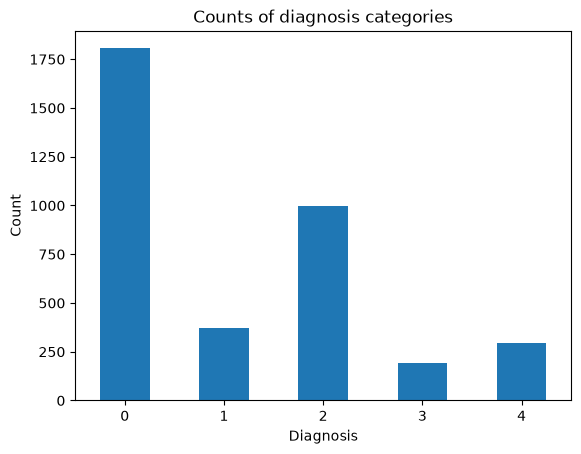

In [20]:
# Bar chart of diagnosis categories
counts = train_df['diagnosis'].value_counts().sort_index()
counts.plot(kind='bar')
plt.xlabel('Diagnosis')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.title('Counts of diagnosis categories')
plt.show()

In [21]:
# How big is the disbalance?
print('Proportion of diagnosis categories:')
print(train_df['diagnosis'].value_counts(normalize=True))

Proportion of diagnosis categories:
diagnosis
0    0.492900
2    0.272802
1    0.101038
4    0.080557
3    0.052703
Name: proportion, dtype: float64


We can see that categories 0 (No DR) and 2 (Moderate) are dominant in the dataset. Due to the class imbalance and the ordinal nature of the task:
 1. Quadratic Weighted Kappa will be used as the primary metric, as it accounts for the distance between classes (confusing 0 with 4 is worse than confusing 0 with 1).
2. For loss function class weighted CrossEntropyLoss or Focal Loss will be considered, as they help when one class has many more samples than another. It stops the model from simply guessing the majority class to get a high overall accuracy.

In [22]:
# Check sizes of the images in the train dataset
np.random.seed(42)
for i in range(5):
    image_id = np.random.choice(train_df['id_code'])
    img_path = os.path.join(DIR_TRAIN, f'{image_id}.png')
    img = Image.open(img_path)
    print(f'Image_{i+1} size: {img.size}')

Image_1 size: (2588, 1958)
Image_2 size: (3216, 2136)
Image_3 size: (2416, 1736)
Image_4 size: (2416, 1736)
Image_5 size: (1050, 1050)


Images in the train dataset are of different sizes, so we will need to resize them before feeding to the network. Given the presence of both rectangular (1-4) and square (5) images, it is also necessary to use padding to avoid distorting proportions.

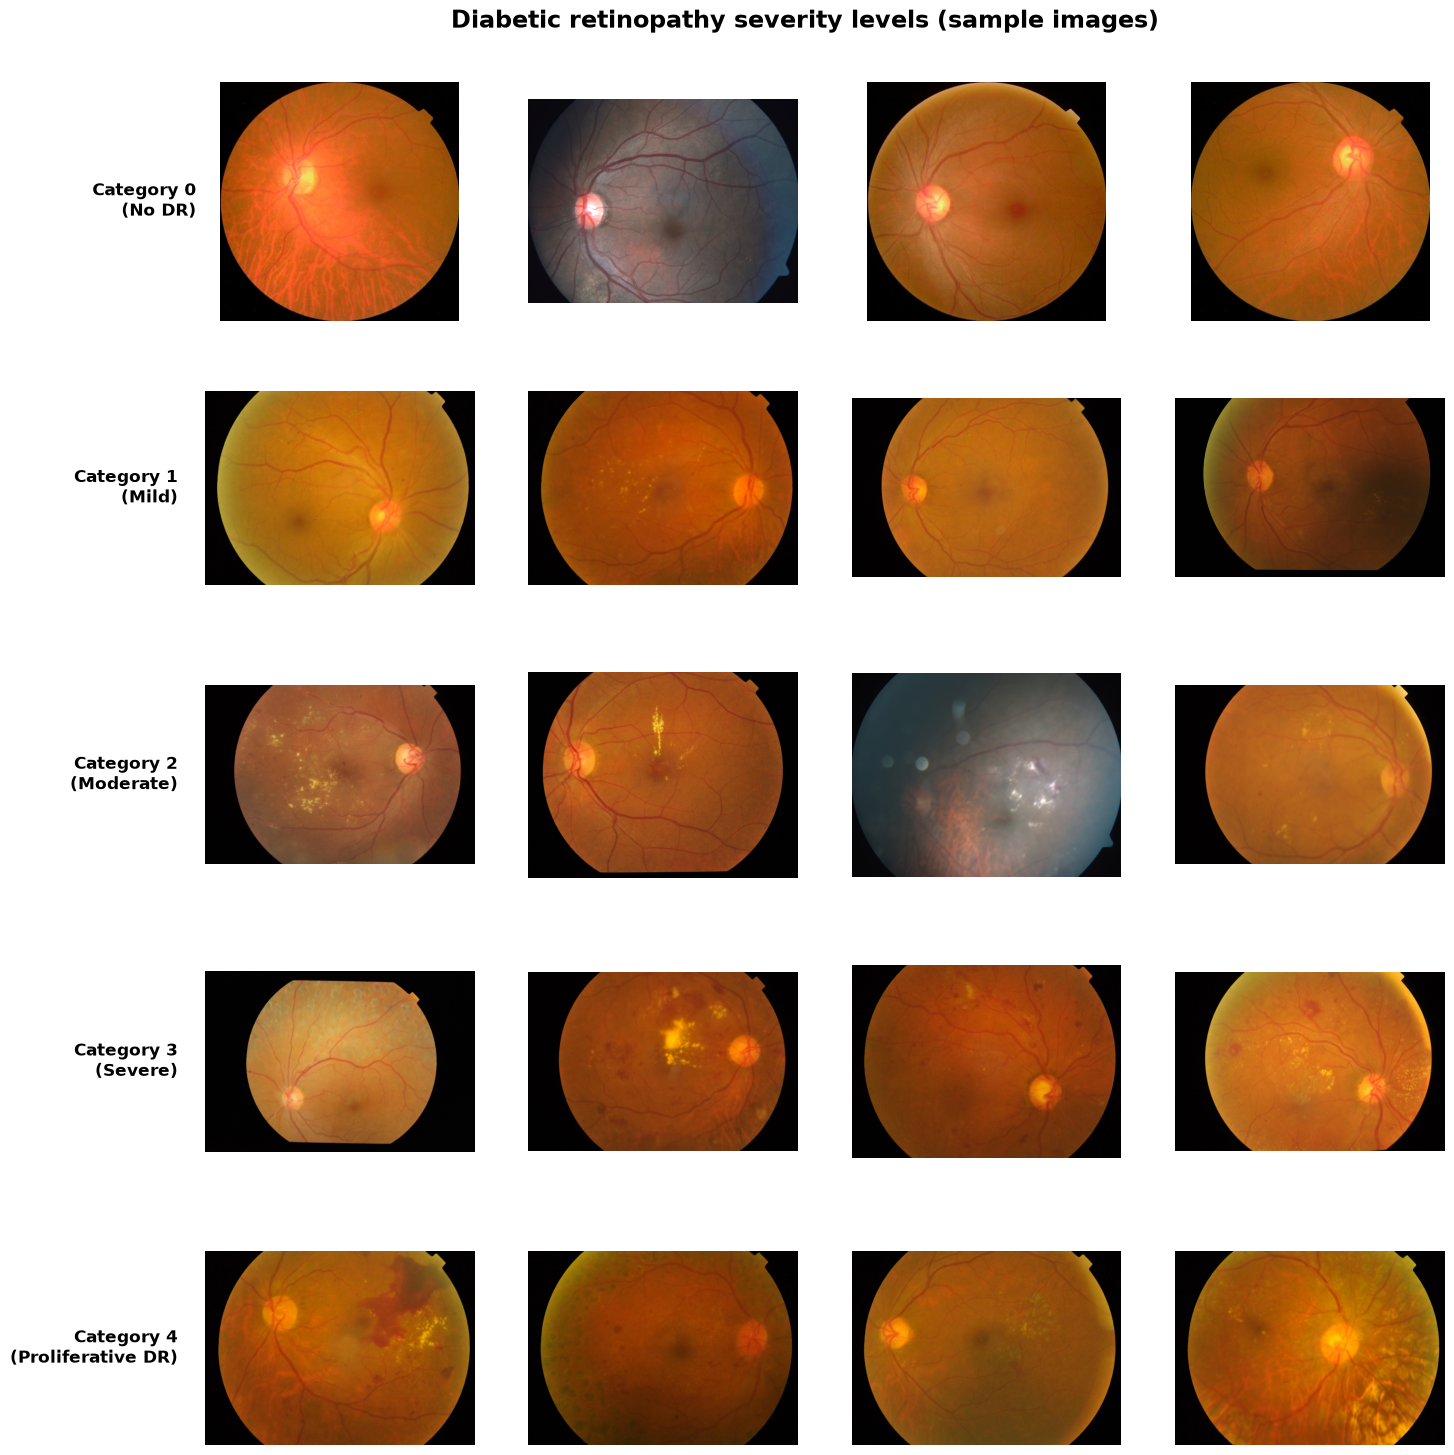

In [23]:
# Look at several examples of each category
severity = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative DR'
}
np.random.seed(42)
fig, axes = plt.subplots(5, 4, figsize=(16, 18))
for cat in range(0, 5):
    filtered_df = train_df[train_df['diagnosis'] == cat]
    random_ids = np.random.choice(filtered_df['id_code'].values, size=4, replace=False)

    for i, image_id in enumerate(random_ids):
        ax = axes[cat, i]
        ax.axis('off')
        img_path = os.path.join(DIR_TRAIN, f'{image_id}.png')
        img = Image.open(img_path)
        ax.imshow(img)
        if i == 0:
            ax.text(-0.1, 0.5, f'Category {cat}\n({severity[cat]})',
                    transform=ax.transAxes, fontsize=12,
                    ha='right', va='center', weight='bold')
fig.suptitle('Diabetic retinopathy severity levels (sample images)',
             fontsize=17, weight='bold', y=0.92)
plt.show()

We can see that:
1. Some images have a noticeably different color balance — grayish-blue (e.g., the second one in category 0). This may be due to differences in cameras or shooting conditions. Contrast or brightness normalization may be required.
2. Images have black borders of different sizes (a form of noise), these edges will need to be cropped.
3. All images have a small mark in the corner (top right for orange images and bottom right for grayish-blue). It may be a signal that indicates two different sources or cameras for the images. This raises an important question: does the camera type (orange vs. grayish-blue) correlate with a specific diagnosis class? If, for instance, all gray-blue images happen to appear more frequently in a specific class, the model might learn to recognize the image source rather than the disease itself (this is a phenomenon known in medical ML as "shortcut learning", where a model exploits simple, unintended patterns in training data to make predictions).

To check whether images of the gray-blue type are evenly distributed across all diagnosis categories or concentrated in specific classes, we first identify them using color saturation (S in the HSV color space), orange (warm) images have high color saturation, while gray-blue (cool) ones have low saturation. Finally, we analyze the proportion of cool images within each diagnosis class.

To read more about HSV color format: https://medium.com/@dijdomv01/a-beginners-guide-to-understand-the-color-models-rgb-and-hsv-244226e4b3e3

In [32]:
# Add HSV statistics for every image
train_df_copy = train_df.copy()
def get_hsv_stat(image_id):
    img_path = os.path.join(DIR_TRAIN, f'{image_id}.png')
    img = Image.open(img_path)
    img_hsv = img.convert('HSV')
    return ImageStat.Stat(img_hsv).mean

train_df_copy['hsv_stat'] = train_df_copy['id_code'].apply(get_hsv_stat)

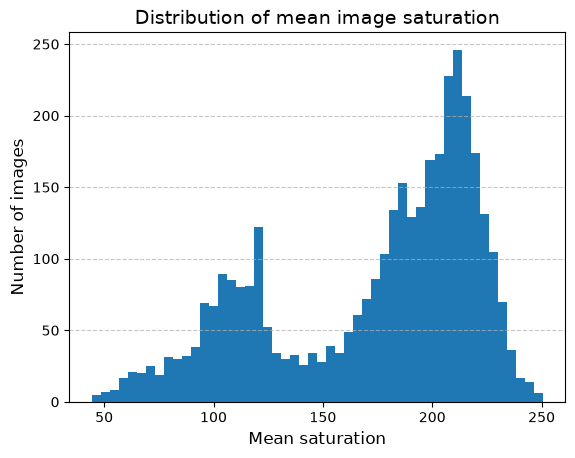

In [33]:
# Extract mean saturation for every image
train_df_copy['s_mean'] = train_df_copy['hsv_stat'].str[1]
# Plot distribution of mean image saturation
plt.hist(train_df_copy['s_mean'], bins=50)
plt.title('Distribution of mean image saturation', fontsize=14)
plt.xlabel('Mean saturation', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We observe a noticeable dip between the two groups at a threshold level of approximately 125-150. Let's look at some examples of images with a saturation value of less than 125.

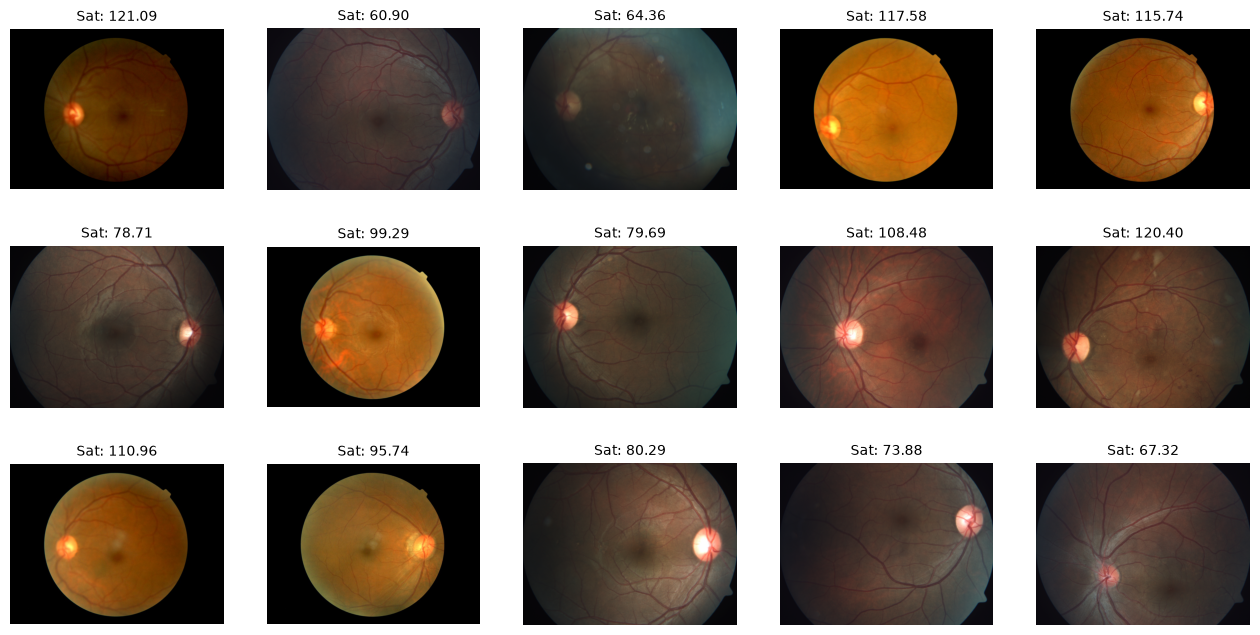

In [34]:
low_saturation = train_df_copy[train_df_copy['s_mean'] < 125][:15]
fig, axes = plt.subplots(3, 5, figsize=(16, 8))
axes = axes.flatten()
for i, (_, row) in enumerate(low_saturation.iterrows()):
    img_path = os.path.join(DIR_TRAIN, f"{row['id_code']}.png")
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Sat: {row['s_mean']:.2f}", fontsize=10)
    axes[i].axis('off')
plt.show()

Several of the displayed images are still of a warm type, so the visual dip in the histogram does not necessarily correspond to what the human eye perceives as a distinctly different type of image.

Now let's lower the threshold to 75 and display some images.

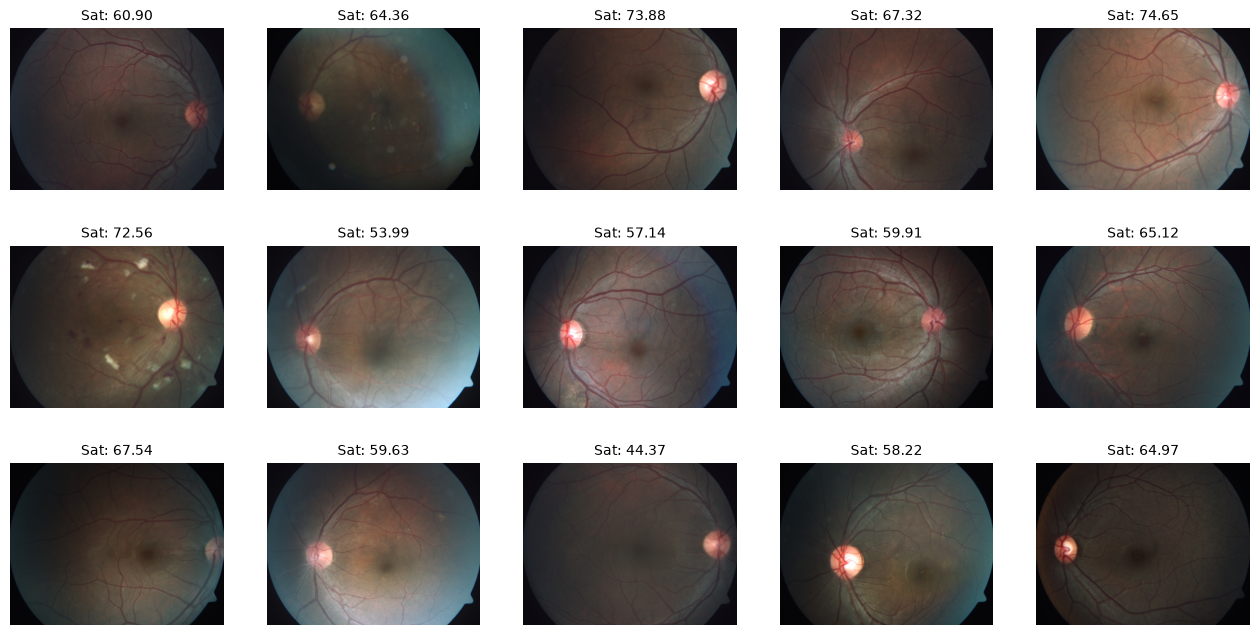

In [35]:
low_saturation = train_df_copy[train_df_copy['s_mean'] < 75][:15]
fig, axes = plt.subplots(3, 5, figsize=(16, 8))
axes = axes.flatten()
for i, (_, row) in enumerate(low_saturation.iterrows()):
    img_path = os.path.join(DIR_TRAIN, f"{row['id_code']}.png")
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Sat: {row['s_mean']:.2f}", fontsize=10)
    axes[i].axis('off')
plt.show()

Displayed images with significantly low saturation are indeed cool. In other words, truly visually cool images fall within the range below 70-80.

Next, we divide the images into low- and high-saturation categories using three different threshold values (since the boundary between cool and warm types is gradual rather than abrupt) and analyze the proportion of low-saturation images (potentially of the cool type) for each of these thresholds.

In [37]:
for thresh in [125, 100, 75]:
    train_df_copy[f"saturation_thresh_{thresh}"] = np.where(
        train_df_copy["s_mean"] < thresh, "low", "high"
    )

# Compute frequency table of saturation levels vs. diagnosis classes
for thresh in [125, 100, 75]:
    print(f'Saturation threshold: {thresh}')
    print(pd.crosstab(train_df_copy[f'saturation_thresh_{thresh}'],
                      train_df_copy['diagnosis'],
                      margins=True))
    print()

Saturation threshold: 125
diagnosis                 0    1    2    3    4   All
saturation_thresh_125                                
high                   1094  358  903  161  268  2784
low                     711   12   96   32   27   878
All                    1805  370  999  193  295  3662

Saturation threshold: 100
diagnosis                 0    1    2    3    4   All
saturation_thresh_100                                
high                   1520  364  951  186  286  3307
low                     285    6   48    7    9   355
All                    1805  370  999  193  295  3662

Saturation threshold: 75
diagnosis                0    1    2    3    4   All
saturation_thresh_75                                
high                  1721  369  979  189  291  3549
low                     84    1   20    4    4   113
All                   1805  370  999  193  295  3662



In [39]:
cols = ["saturation_thresh_125", "saturation_thresh_100", "saturation_thresh_75"]
table = (train_df_copy[cols] == "low").groupby(
    train_df_copy["diagnosis"]
).mean().T * 100

table["Dataset mean"] = (train_df_copy[cols] == "low").mean(axis=0) * 100
table.index = [125, 100, 75]
table.index.name = "Threshold"
table.columns = [f"Class {c}" if isinstance(c, int) else c for c in table.columns]

print("Proportion of low-saturation (cool) images by diagnosis class (%):\n")
print(table.map("{:.1f}%".format).reset_index().to_string(index=False))

Proportion of low-saturation (cold) images by diagnosis class (%):

 Threshold Class 0 Class 1 Class 2 Class 3 Class 4 Dataset mean
       125   39.4%    3.2%    9.6%   16.6%    9.2%        24.0%
       100   15.8%    1.6%    4.8%    3.6%    3.1%         9.7%
        75    4.7%    0.3%    2.0%    2.1%    1.4%         3.1%


Regardless of the threshold, class 0 always has the highest proportion of low-saturation (cool) images, higher than the dataset average and all other classes. The direction of the effect is consistent, confirming a risk of shortcut learning. Preprocessing requirement: normalization must be aggressive enough to eliminate the difference between warm and cool images before the data is fed into the model.

In [40]:
# Check sizes of train images
file_names = [name for name in os.listdir(DIR_TRAIN)]
file_sizes = [os.path.getsize(os.path.join(DIR_TRAIN, name))
         for name in file_names]
print('Description of file sizes in the train dataset:')
print(pd.DataFrame(file_sizes).describe())

Description of file sizes in the train dataset:
                  0
count  3.662000e+03
mean   2.349280e+06
std    1.762452e+06
min    2.217370e+05
25%    1.003996e+06
50%    1.934951e+06
75%    2.846848e+06
max    7.674292e+06


We observe a healthy distribution of file sizes. Average size is ~2.35 MB (Median: ~1.93 MB), no severe skewness. Range is from ~221 KB to ~7.67 MB.

### Key observations

1. Class imbalance + ordinal nature -> Quadratic Weighted Kappa as primary metric and considering class weighted CrossEntropyLoss or Focal Loss.
2. Pad and resize images before feeding to the network as they are of different shapes.
3. Two image types (source/camera) — majority of warm (orange) images, while some are cool (gray-blue).
4. Class 0 has the highest proportion of cool images -> Risk of shortcut learning. Normalization to eliminate the difference between warm and cool images before the data is fed into the model.